<a href="https://colab.research.google.com/github/kokkalgavesusmitha1712-dot/healthcare-claims-pipeline/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Healthcare Claims Analytics Pipeline
## Notebook 01 — Data Exploration & EDA

**Author:** Sushmitha Kokkalgave  
**Project:** Healthcare Claims Analytics Pipeline  
**GitHub:** [healthcare-claims-pipeline](https://github.com/sushmitha-kokkalgave/healthcare-claims-pipeline)

---

### What this notebook covers
1. Load and inspect raw claims data
2. Data quality overview — nulls, duplicates, data types
3. Claims volume analysis — by month, type, and region
4. Financial analysis — billed vs paid vs allowed amounts
5. Approval & denial rate breakdown
6. Processing time distribution
7. KPI summary dashboard
8. Key findings & next steps

---


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize':    (12, 5),
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.size':         11,
})
sns.set_palette('Blues_d')

print("Libraries loaded ✓")
print(f"Pandas  version: {pd.__version__}")
print(f"NumPy   version: {np.__version__}")


Libraries loaded ✓
Pandas  version: 2.2.2
NumPy   version: 2.0.2


## 2. Load Data

In [2]:
# ── Generate sample data inline so the notebook runs standalone ──
np.random.seed(42)
N = 500

MONTHS        = pd.date_range('2023-01-01', '2024-12-01', freq='MS')
claim_types   = ['medical', 'pharmacy', 'dental', 'vision', 'behavioral']
statuses      = ['approved', 'denied', 'pending', 'under_review']
status_wts    = [0.70, 0.18, 0.08, 0.04]
denial_reasons= ['not covered', 'prior auth required', 'duplicate claim',
                 'out of network', 'exceeded benefit limit']
regions       = ['Northeast', 'Southeast', 'Midwest', 'Southwest', 'West']
plan_types    = ['PPO', 'HMO', 'EPO', 'HDHP']

dates = pd.to_datetime(
    np.random.choice(pd.date_range('2023-01-01', '2024-12-31'), N)
)

df = pd.DataFrame({
    'claim_id':        [f'CLM{str(i).zfill(5)}' for i in range(1, N+1)],
    'member_id':       [f'MBR{np.random.randint(1000,9999)}' for _ in range(N)],
    'provider_id':     [f'PRV{np.random.randint(100,999)}'   for _ in range(N)],
    'claim_date':      dates,
    'claim_type':      np.random.choice(claim_types, N),
    'billed_amount':   np.round(np.random.uniform(50, 5000, N), 2),
    'allowed_amount':  np.round(np.random.uniform(40, 4500, N), 2),
    'paid_amount':     np.round(np.random.uniform(30, 4000, N), 2),
    'claim_status':    np.random.choice(statuses, N, p=status_wts),
    'processing_days': np.random.randint(1, 20, N),
    'region':          np.random.choice(regions, N),
    'plan_type':       np.random.choice(plan_types, N),
})
df.loc[df['claim_status'] == 'denied', 'denial_reason'] = np.random.choice(
    denial_reasons, (df['claim_status'] == 'denied').sum()
)
df['claim_year_month'] = df['claim_date'].dt.to_period('M').astype(str)
df['is_approved']      = df['claim_status'] == 'approved'
df['is_denied']        = df['claim_status'] == 'denied'
df['cost_variance']    = df['billed_amount'] - df['paid_amount']

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset loaded: 500 rows × 17 columns


,claim_id,member_id,provider_id,claim_date,claim_type,billed_amount,allowed_amount,paid_amount,claim_status,processing_days,region,plan_type,denial_reason,claim_year_month,is_approved,is_denied,cost_variance
0,CLM00001,MBR5000,PRV309,2023-04-13,behavioral,3837.69,4186.09,1433.24,pending,15,Northeast,EPO,NaN,2023-04,False,False,2404.45
1,CLM00002,MBR6052,PRV722,2024-03-11,pharmacy,4632.09,3530.32,1850.11,approved,12,Northeast,EPO,NaN,2024-03,True,False,2781.98
2,CLM00003,MBR3738,PRV715,2023-09-28,medical,2218.95,290.37,180.79,denied,8,Midwest,PPO,exceeded benefit limit,2023-09,False,True,2038.16
3,CLM00004,MBR6732,PRV927,2023-04-17,vision,4511.81,3843.17,2991.06,approved,6,West,PPO,NaN,2023-04,True,False,1520.75
4,CLM00005,MBR6387,PRV782,2023-03-13,vision,4395.56,1045.91,2210.81,denied,3,Midwest,EPO,not covered,2023-03,False,True,2184.75


## 3. Data Quality Overview

In [3]:
print("=" * 55)
print("  SCHEMA OVERVIEW")
print("=" * 55)
print(df.dtypes.to_string())
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")


  SCHEMA OVERVIEW
claim_id                    object
member_id                   object
provider_id                 object
claim_date          datetime64[ns]
claim_type                  object
billed_amount              float64
allowed_amount             float64
paid_amount                float64
claim_status                object
processing_days              int64
region                      object
plan_type                   object
denial_reason               object
claim_year_month            object
is_approved                   bool
is_denied                     bool
cost_variance              float64

Shape: 500 rows × 17 columns


In [4]:
# Null audit
null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct':   (df.isnull().sum() / len(df) * 100).round(2)
}).query('null_count > 0').sort_values('null_pct', ascending=False)

print("Columns with nulls:")
print(null_summary.to_string() if not null_summary.empty else "  None — clean dataset!")


Columns with nulls:
               null_count  null_pct
denial_reason         392      78.4


In [5]:
# Duplicate check
dup_count = df['claim_id'].duplicated().sum()
print(f"Duplicate claim_ids : {dup_count}")
print(f"Unique members      : {df['member_id'].nunique():,}")
print(f"Unique providers    : {df['provider_id'].nunique():,}")
print(f"Date range          : {df['claim_date'].min().date()} → {df['claim_date'].max().date()}")


Duplicate claim_ids : 0
Unique members      : 477
Unique providers    : 371
Date range          : 2023-01-02 → 2024-12-30


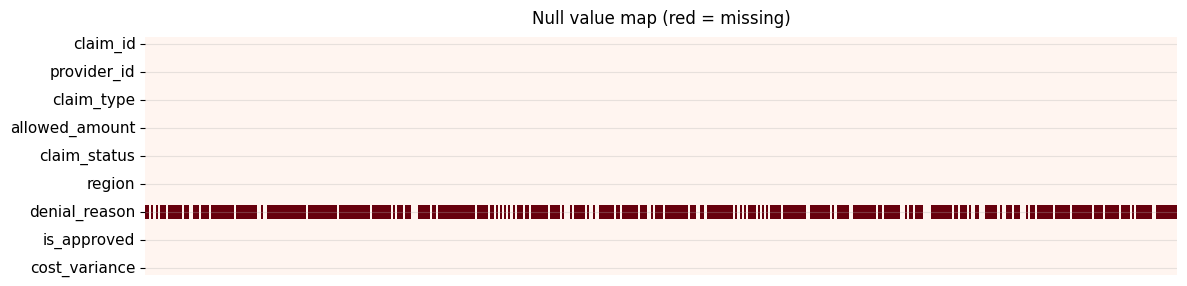

In [6]:
# Visual null heatmap
fig, ax = plt.subplots(figsize=(12, 3))
null_matrix = df.isnull().astype(int)
sns.heatmap(null_matrix.T, cmap='Reds', cbar=False,
            xticklabels=False, ax=ax, linewidths=0)
ax.set_title('Null value map (red = missing)', fontsize=12, pad=10)
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 4. Claims Volume Analysis

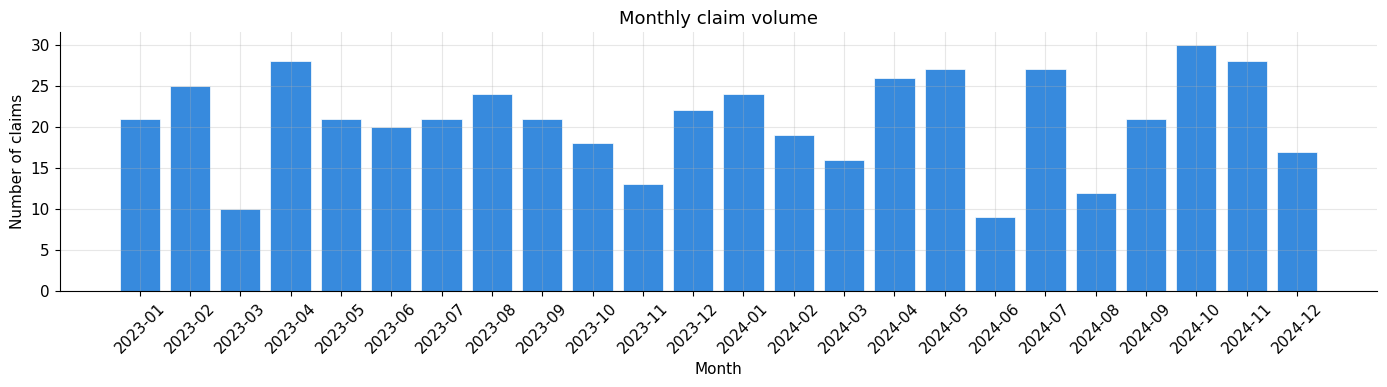

Peak month   : 2024-10 (30 claims)
Average/month: 21 claims


In [7]:
# Monthly claim volume
monthly = df.groupby('claim_year_month').size().reset_index(name='claim_count')

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly['claim_year_month'], monthly['claim_count'],
       color='#378ADD', edgecolor='white', linewidth=0.5)
ax.set_title('Monthly claim volume', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Number of claims')
ax.tick_params(axis='x', rotation=45)
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
print(f"Peak month   : {monthly.loc[monthly['claim_count'].idxmax(), 'claim_year_month']} "
      f"({monthly['claim_count'].max()} claims)")
print(f"Average/month: {monthly['claim_count'].mean():.0f} claims")


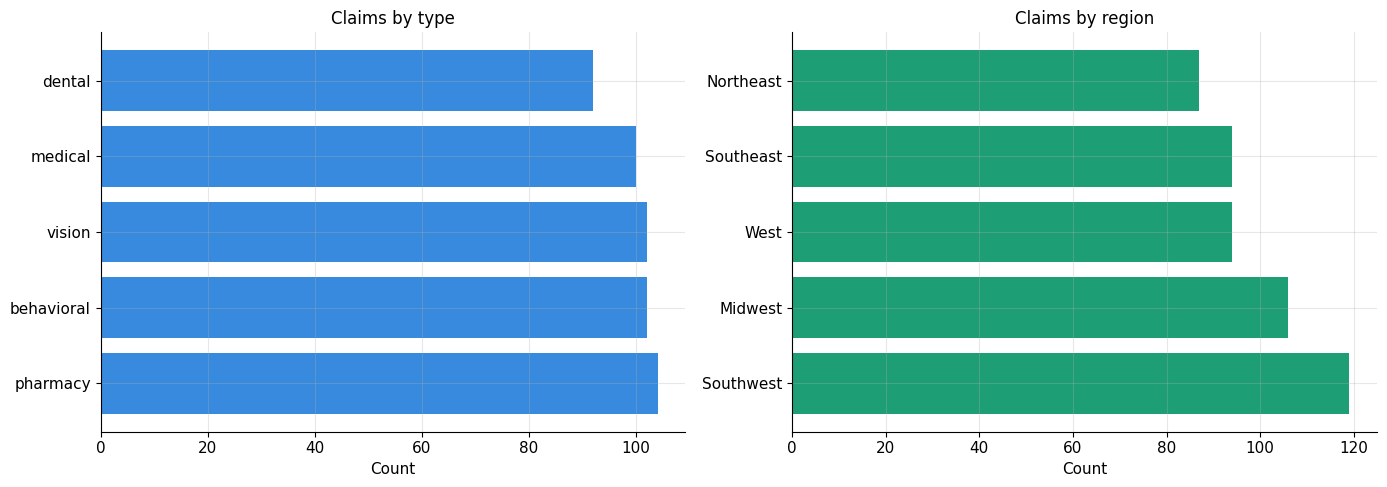

In [8]:
# Claims by type and region — side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = df['claim_type'].value_counts()
axes[0].barh(type_counts.index, type_counts.values, color='#378ADD')
axes[0].set_title('Claims by type', fontsize=12)
axes[0].set_xlabel('Count')
for spine in ['top','right']: axes[0].spines[spine].set_visible(False)

region_counts = df['region'].value_counts()
axes[1].barh(region_counts.index, region_counts.values, color='#1D9E75')
axes[1].set_title('Claims by region', fontsize=12)
axes[1].set_xlabel('Count')
for spine in ['top','right']: axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


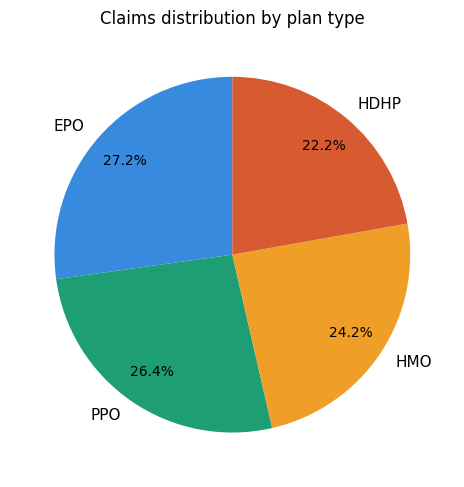

In [9]:
# Claims by plan type — pie chart
fig, ax = plt.subplots(figsize=(7, 5))
plan_counts = df['plan_type'].value_counts()
colors = ['#378ADD', '#1D9E75', '#EF9F27', '#D85A30']
wedges, texts, autotexts = ax.pie(
    plan_counts.values,
    labels=plan_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.8
)
for at in autotexts: at.set_fontsize(10)
ax.set_title('Claims distribution by plan type', fontsize=12)
plt.tight_layout()
plt.show()


## 5. Financial Analysis — Billed vs Paid vs Allowed

In [10]:
# Summary stats
fin = df[['billed_amount','allowed_amount','paid_amount']].describe().round(2)
print("Financial summary:")
print(fin.to_string())


Financial summary:
       billed_amount  allowed_amount  paid_amount
count         500.00          500.00       500.00
mean         2493.90         2246.57      2064.30
std          1383.68         1311.54      1152.51
min            51.65           40.84        31.76
25%          1249.74         1082.88      1088.20
50%          2557.04         2180.74      2125.85
75%          3692.82         3426.36      3052.73
max          4977.63         4498.72      3998.19


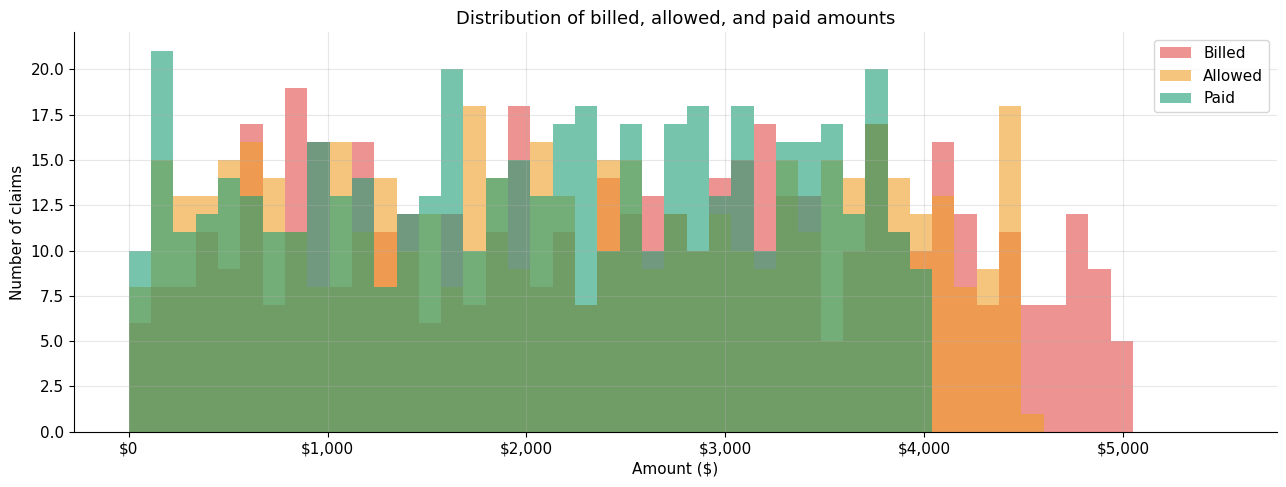

Total billed : $1,246,948.56
Total paid   : $1,032,151.66
Payment ratio: 82.8%  (paid / billed)


In [11]:
# Billed vs allowed vs paid distributions
fig, ax = plt.subplots(figsize=(13, 5))
bins = np.linspace(0, 5500, 50)
ax.hist(df['billed_amount'],  bins=bins, alpha=0.6, label='Billed',  color='#E24B4A')
ax.hist(df['allowed_amount'], bins=bins, alpha=0.6, label='Allowed', color='#EF9F27')
ax.hist(df['paid_amount'],    bins=bins, alpha=0.6, label='Paid',    color='#1D9E75')
ax.set_title('Distribution of billed, allowed, and paid amounts', fontsize=13)
ax.set_xlabel('Amount ($)')
ax.set_ylabel('Number of claims')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=11)
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

total_billed   = df['billed_amount'].sum()
total_paid     = df['paid_amount'].sum()
payment_ratio  = total_paid / total_billed * 100
print(f"Total billed : ${total_billed:>12,.2f}")
print(f"Total paid   : ${total_paid:>12,.2f}")
print(f"Payment ratio: {payment_ratio:.1f}%  (paid / billed)")


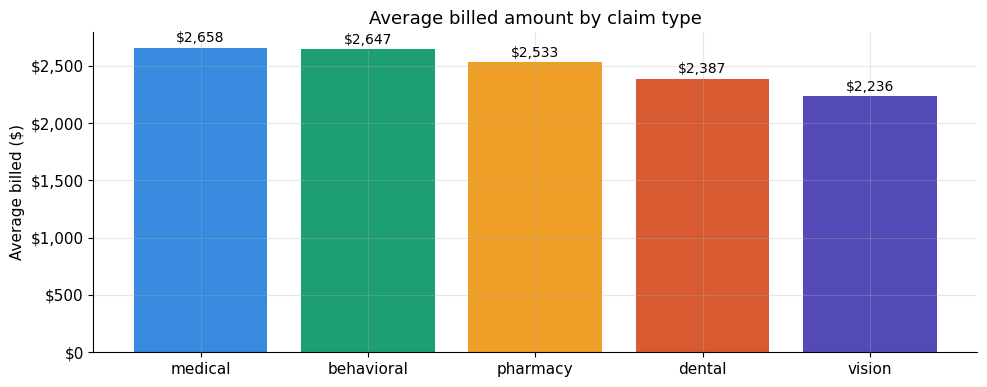

In [12]:
# Average billed amount by claim type
avg_by_type = df.groupby('claim_type')['billed_amount'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(avg_by_type.index, avg_by_type.values,
              color=['#378ADD','#1D9E75','#EF9F27','#D85A30','#534AB7'])
ax.set_title('Average billed amount by claim type', fontsize=13)
ax.set_ylabel('Average billed ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, avg_by_type.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=10)
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


## 6. Approval & Denial Rate Analysis

In [13]:
# Overall status breakdown
status_counts = df['claim_status'].value_counts()
total = len(df)

print("Claim status breakdown:")
for status, count in status_counts.items():
    bar = '█' * int(count / total * 40)
    print(f"  {status:<15s} {count:4d}  ({count/total*100:.1f}%)  {bar}")


Claim status breakdown:
  approved         337  (67.4%)  ██████████████████████████
  denied           108  (21.6%)  ████████
  pending           39  (7.8%)  ███
  under_review      16  (3.2%)  █


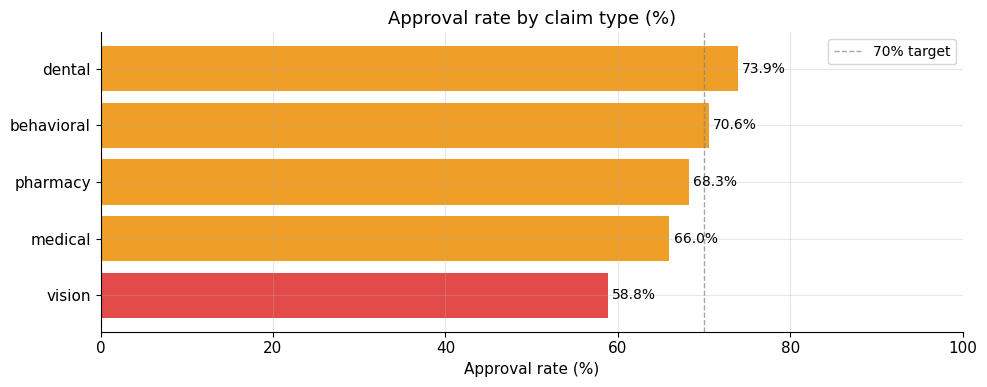

In [14]:
# Approval rate by claim type
approval_by_type = (
    df.groupby('claim_type')
    .agg(total=('claim_id','count'), approved=('is_approved','sum'))
    .assign(approval_rate=lambda x: x['approved'] / x['total'] * 100)
    .sort_values('approval_rate', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 4))
colors_bar = ['#E24B4A' if r < 65 else '#EF9F27' if r < 75 else '#1D9E75'
              for r in approval_by_type['approval_rate']]
bars = ax.barh(approval_by_type.index, approval_by_type['approval_rate'],
               color=colors_bar)
ax.axvline(70, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='70% target')
ax.set_title('Approval rate by claim type (%)', fontsize=13)
ax.set_xlabel('Approval rate (%)')
ax.set_xlim(0, 100)
for bar, val in zip(bars, approval_by_type['approval_rate']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.legend(fontsize=10)
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


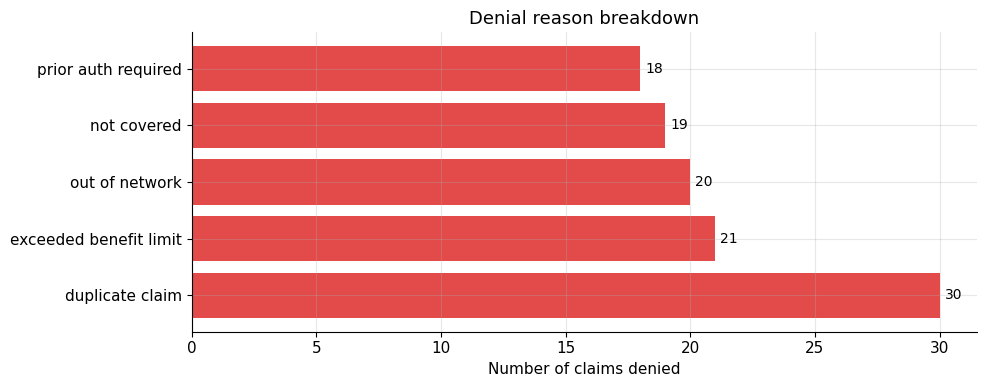

Total denied       : 108
Top denial reason  : duplicate claim (30 claims)


In [15]:
# Denial reasons breakdown
denied = df[df['is_denied'] & df['denial_reason'].notna()]
denial_counts = denied['denial_reason'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(denial_counts.index, denial_counts.values, color='#E24B4A')
ax.set_title('Denial reason breakdown', fontsize=13)
ax.set_xlabel('Number of claims denied')
for bar, val in zip(bars, denial_counts.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()
print(f"Total denied       : {len(denied):,}")
print(f"Top denial reason  : {denial_counts.index[0]} ({denial_counts.iloc[0]} claims)")


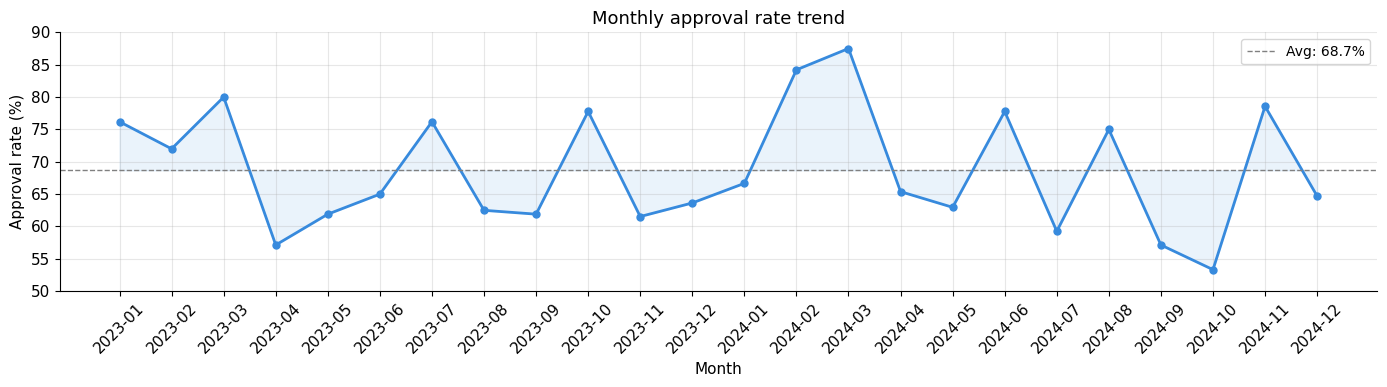

In [16]:
# Monthly approval rate trend
monthly_approval = (
    df.groupby('claim_year_month')
    .agg(total=('claim_id','count'), approved=('is_approved','sum'))
    .assign(approval_rate=lambda x: x['approved'] / x['total'] * 100)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_approval['claim_year_month'],
        monthly_approval['approval_rate'],
        color='#378ADD', linewidth=2, marker='o', markersize=5)
ax.axhline(monthly_approval['approval_rate'].mean(),
           color='gray', linestyle='--', linewidth=1,
           label=f"Avg: {monthly_approval['approval_rate'].mean():.1f}%")
ax.fill_between(monthly_approval['claim_year_month'],
                monthly_approval['approval_rate'],
                monthly_approval['approval_rate'].mean(),
                alpha=0.1, color='#378ADD')
ax.set_title('Monthly approval rate trend', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Approval rate (%)')
ax.set_ylim(50, 90)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
for spine in ['top','right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


## 7. Processing Time Analysis

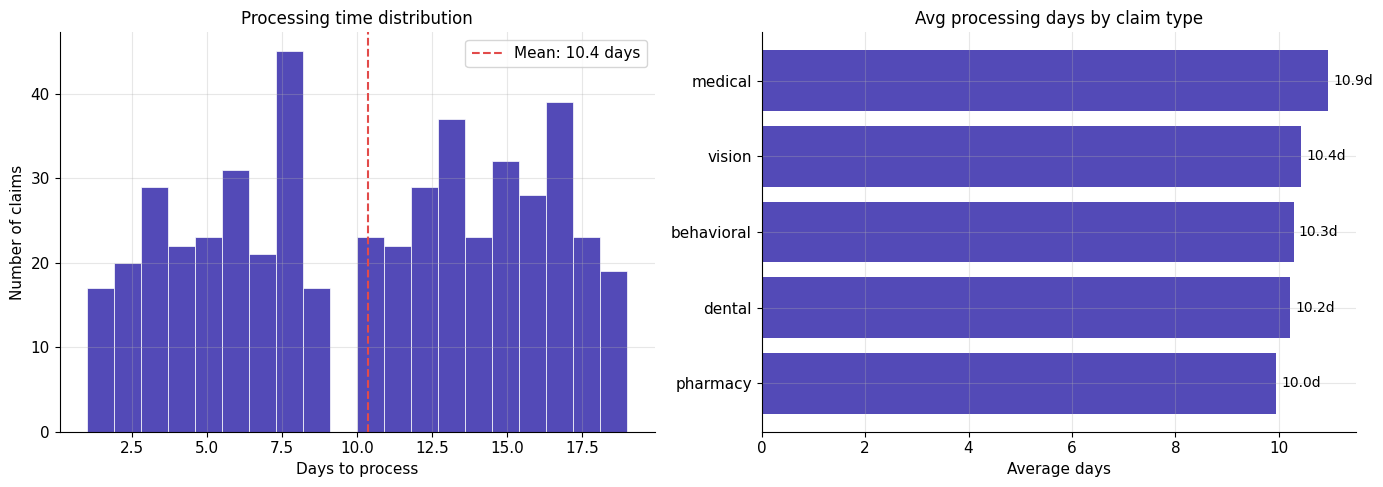

Avg processing time    : 10.4 days
Median processing time : 11.0 days
% processed in ≤5 days : 22.2%


In [17]:
# Processing time distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['processing_days'], bins=20,
             color='#534AB7', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['processing_days'].mean(), color='#E24B4A',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {df['processing_days'].mean():.1f} days")
axes[0].set_title('Processing time distribution', fontsize=12)
axes[0].set_xlabel('Days to process')
axes[0].set_ylabel('Number of claims')
axes[0].legend()
for spine in ['top','right']: axes[0].spines[spine].set_visible(False)

avg_pt = df.groupby('claim_type')['processing_days'].mean().sort_values()
axes[1].barh(avg_pt.index, avg_pt.values, color='#534AB7')
axes[1].set_title('Avg processing days by claim type', fontsize=12)
axes[1].set_xlabel('Average days')
for bar, val in zip(axes[1].patches, avg_pt.values):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}d', va='center', fontsize=10)
for spine in ['top','right']: axes[1].spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

pct_under_5 = (df['processing_days'] <= 5).sum() / len(df) * 100
print(f"Avg processing time    : {df['processing_days'].mean():.1f} days")
print(f"Median processing time : {df['processing_days'].median():.1f} days")
print(f"% processed in ≤5 days : {pct_under_5:.1f}%")


## 8. KPI Summary Dashboard

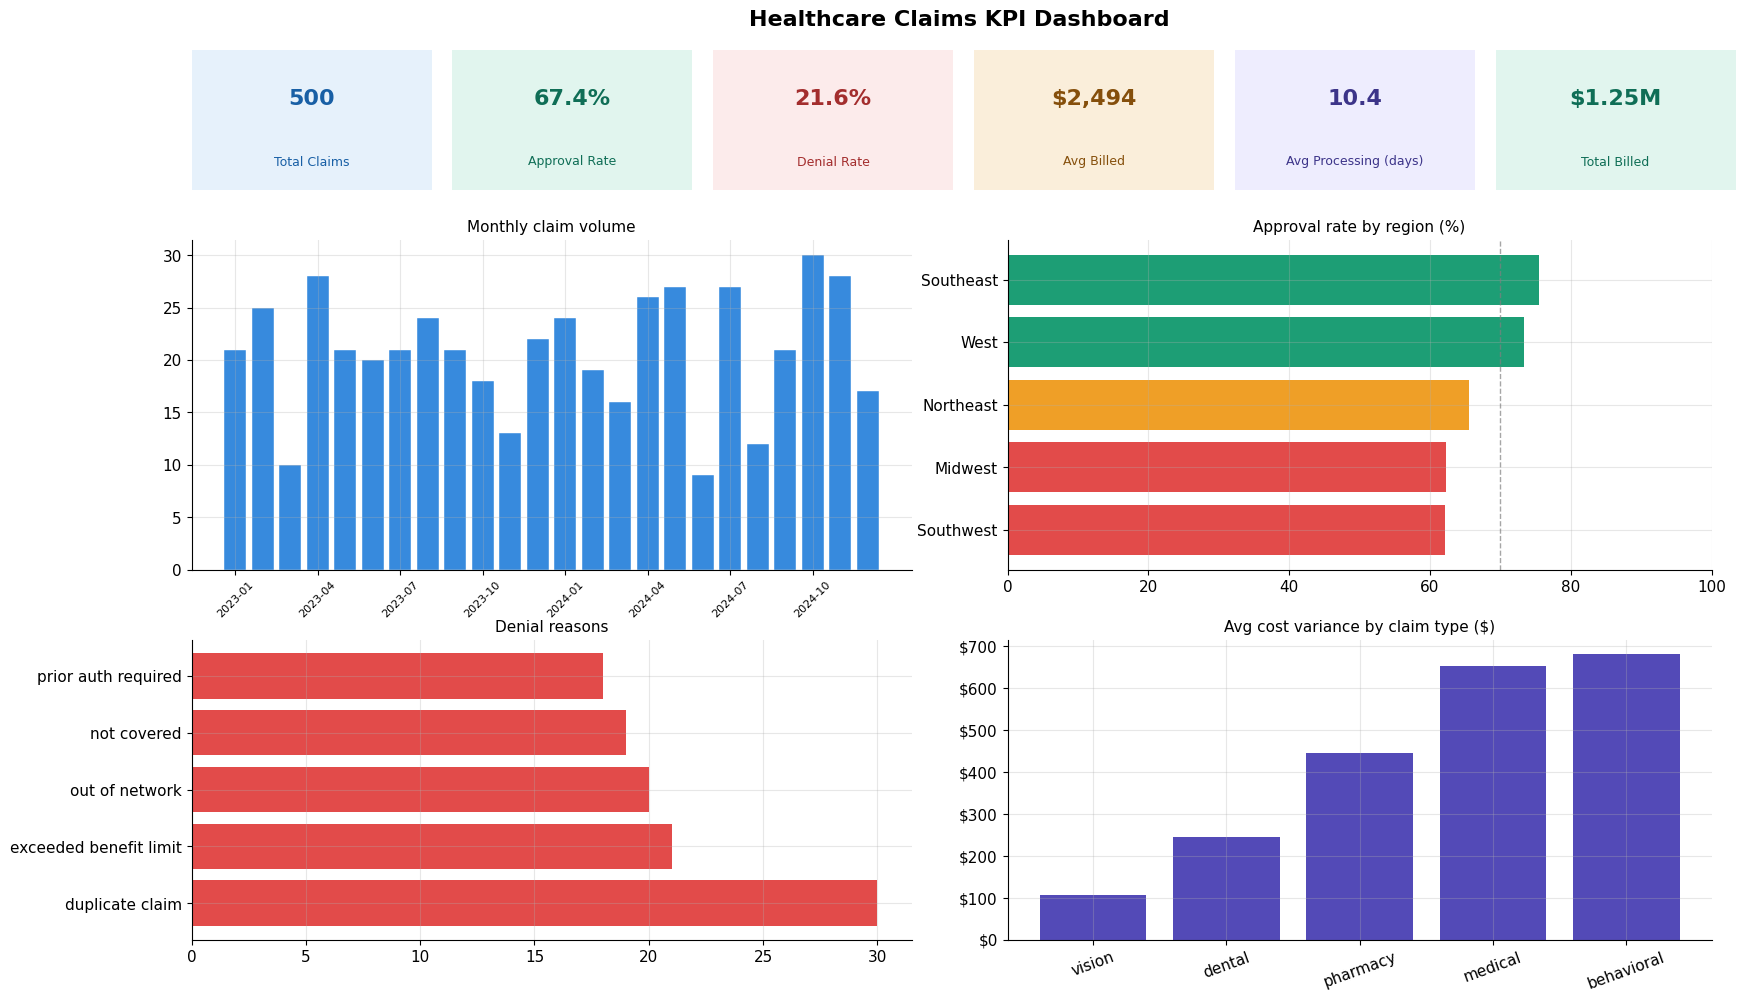

Dashboard saved → kpi_dashboard.png


In [18]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Healthcare Claims KPI Dashboard', fontsize=16, fontweight='bold', y=0.98)

# ── KPI metric boxes ──────────────────────────────────────────────
kpis = [
    ('Total Claims',          f"{len(df):,}",              '#E6F1FB', '#185FA5'),
    ('Approval Rate',         f"{df['is_approved'].mean()*100:.1f}%", '#E1F5EE', '#0F6E56'),
    ('Denial Rate',           f"{df['is_denied'].mean()*100:.1f}%",   '#FCEBEB', '#A32D2D'),
    ('Avg Billed',            f"${df['billed_amount'].mean():,.0f}",   '#FAEEDA', '#854F0B'),
    ('Avg Processing (days)', f"{df['processing_days'].mean():.1f}",  '#EEEDFE', '#3C3489'),
    ('Total Billed',          f"${df['billed_amount'].sum()/1e6:.2f}M",'#E1F5EE','#0F6E56'),
]
for i, (label, value, bg, fg) in enumerate(kpis):
    ax = fig.add_axes([0.02 + i*0.163, 0.80, 0.15, 0.14])
    ax.set_facecolor(bg)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.text(0.5, 0.65, value, ha='center', va='center',
            fontsize=16, fontweight='bold', color=fg, transform=ax.transAxes)
    ax.text(0.5, 0.20, label, ha='center', va='center',
            fontsize=9, color=fg, transform=ax.transAxes)

# ── Top left: monthly volume ──────────────────────────────────────
ax1 = fig.add_axes([0.02, 0.42, 0.45, 0.33])
monthly = df.groupby('claim_year_month').size().reset_index(name='n')
ax1.bar(range(len(monthly)), monthly['n'], color='#378ADD', edgecolor='white', linewidth=0.3)
ax1.set_title('Monthly claim volume', fontsize=11)
ax1.set_xticks(range(0, len(monthly), 3))
ax1.set_xticklabels(monthly['claim_year_month'].iloc[::3], rotation=45, fontsize=8)
for spine in ['top','right']: ax1.spines[spine].set_visible(False)

# ── Top right: approval by region ────────────────────────────────
ax2 = fig.add_axes([0.53, 0.42, 0.44, 0.33])
apr = df.groupby('region').agg(t=('claim_id','count'), a=('is_approved','sum'))
apr['rate'] = apr['a'] / apr['t'] * 100
apr = apr.sort_values('rate')
colors_r = ['#E24B4A' if r < 65 else '#EF9F27' if r < 73 else '#1D9E75' for r in apr['rate']]
ax2.barh(apr.index, apr['rate'], color=colors_r)
ax2.axvline(70, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_title('Approval rate by region (%)', fontsize=11)
ax2.set_xlim(0, 100)
for spine in ['top','right']: ax2.spines[spine].set_visible(False)

# ── Bottom left: denial reasons ───────────────────────────────────
ax3 = fig.add_axes([0.02, 0.05, 0.45, 0.30])
dc = df[df['is_denied'] & df['denial_reason'].notna()]['denial_reason'].value_counts()
ax3.barh(dc.index, dc.values, color='#E24B4A')
ax3.set_title('Denial reasons', fontsize=11)
for spine in ['top','right']: ax3.spines[spine].set_visible(False)

# ── Bottom right: cost variance by type ──────────────────────────
ax4 = fig.add_axes([0.53, 0.05, 0.44, 0.30])
cv = df.groupby('claim_type')['cost_variance'].mean().sort_values()
ax4.bar(cv.index, cv.values, color='#534AB7')
ax4.set_title('Avg cost variance by claim type ($)', fontsize=11)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax4.tick_params(axis='x', rotation=20)
for spine in ['top','right']: ax4.spines[spine].set_visible(False)

plt.savefig('kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved → kpi_dashboard.png")


## 9. Correlation Analysis

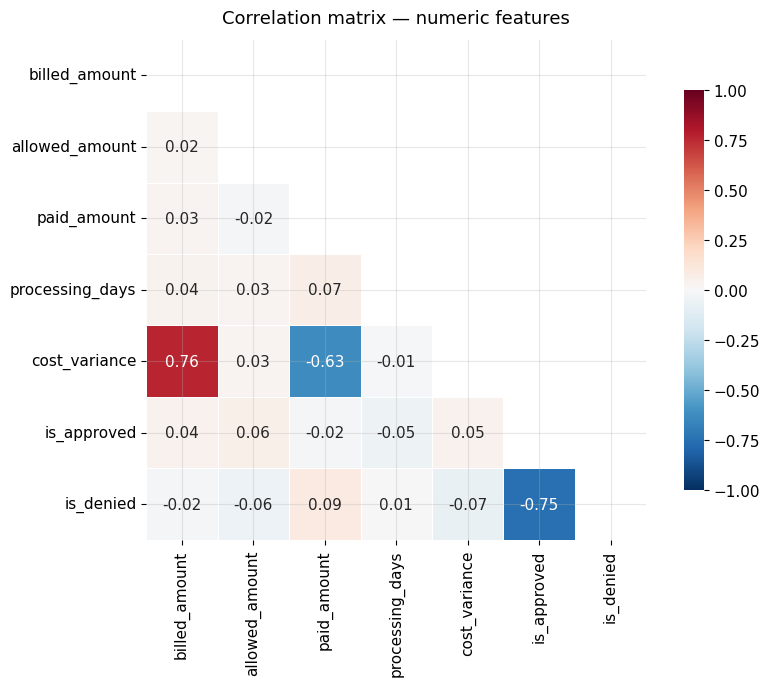

In [19]:
numeric_cols = ['billed_amount','allowed_amount','paid_amount',
                'processing_days','cost_variance','is_approved','is_denied']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix — numeric features', fontsize=13, pad=12)
plt.tight_layout()
plt.show()


## 10. Key Findings & Next Steps

In [20]:
approval_rate  = df['is_approved'].mean() * 100
denial_rate    = df['is_denied'].mean()  * 100
avg_processing = df['processing_days'].mean()
total_billed   = df['billed_amount'].sum()
total_paid     = df['paid_amount'].sum()
payment_ratio  = total_paid / total_billed * 100
top_denial     = df[df['is_denied'] & df['denial_reason'].notna()]['denial_reason'].value_counts().index[0]
top_region     = df.groupby('region')['is_approved'].mean().idxmax()

print("=" * 55)
print("  KEY FINDINGS — HEALTHCARE CLAIMS EDA")
print("=" * 55)
print(f"  Total claims analysed  : {len(df):,}")
print(f"  Date range             : {df['claim_date'].min().date()} → {df['claim_date'].max().date()}")
print()
print(f"  Approval rate          : {approval_rate:.1f}%")
print(f"  Denial rate            : {denial_rate:.1f}%")
print(f"  Top denial reason      : '{top_denial}'")
print()
print(f"  Total billed           : ${total_billed:>12,.2f}")
print(f"  Total paid             : ${total_paid:>12,.2f}")
print(f"  Payment ratio          : {payment_ratio:.1f}%")
print()
print(f"  Avg processing time    : {avg_processing:.1f} days")
print(f"  Best approval region   : {top_region}")
print()
print("  NEXT STEPS")
print("  ─────────────────────────────────────────────────")
print("  1. Run the full ETL pipeline → pipelines/")
print("  2. Explore KPI trends → 02_pipeline_validation.ipynb")
print("  3. Build Power BI dashboard → dashboards/powerbi/")
print("  4. Schedule with Airflow → see airflow/ folder")
print("=" * 55)


  KEY FINDINGS — HEALTHCARE CLAIMS EDA
  Total claims analysed  : 500
  Date range             : 2023-01-02 → 2024-12-30

  Approval rate          : 67.4%
  Denial rate            : 21.6%
  Top denial reason      : 'duplicate claim'

  Total billed           : $1,246,948.56
  Total paid             : $1,032,151.66
  Payment ratio          : 82.8%

  Avg processing time    : 10.4 days
  Best approval region   : Southeast

  NEXT STEPS
  ─────────────────────────────────────────────────
  1. Run the full ETL pipeline → pipelines/
  2. Explore KPI trends → 02_pipeline_validation.ipynb
  3. Build Power BI dashboard → dashboards/powerbi/
  4. Schedule with Airflow → see airflow/ folder
